# Boosted Decision Tree Example

This example notebook illustrates supervised learning using a Boosted Decision Tree.

## MAGIC Dataset
The example uses a simulated dataset from the Major Atmospheric Gamma Imaging Cerekenov (MAGIC) telescopes [1]. These telescopes image particle air showers, produced when high energy cosmic rays enter the upper atmosphere, using the Cerenkov light emitted by particles travelling faster than the speed of light through a medium. The goal of MAGIC is to observe very high energy (up to 30 TeV) gamma rays from galactic sources.

The dataset contains the simulated detector response to ~19,000 air showers, produced by initial gamma rays and hadrons. The data comprises 10 variables that characterise the clusters observed by the MAGIC camera, together with a class label that indicates whether the cluster originated from a gamma or a hadron.

The data file can be downloaded from https://archive.ics.uci.edu/dataset/159/magic+gamma+telescope

[1] - Cortina, J. Status and First Results of the Magic Telescope. Astrophys Space Sci 297, 245–255 (2005). https://doi.org/10.1007/s10509-005-7627-5

## Goal of Machine Learning

The goal in this example is to train an ML model to classify a cluster as gamma (signal) or hadron (background), based on the 10 cluster shape variables.  To do this we will use a Gradient Boosted Decision Tree, from the sci-kit learn library.


## Reading the data

First we read in the data file using pandas, and confirm it includes tabular .

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

# read in the data
df = pd.read_csv('magic04.data', names=['fLength','fWidth','fSize','fConc','fConc1','fAsym','fM3Long','fM3Trans','fAlpha','fDist','class'])

Index(['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym', 'fM3Long',
       'fM3Trans', 'fAlpha', 'fDist', 'class'],
      dtype='object')


And next we look at the distribution of each variable for the gamma and hadron classes separately.

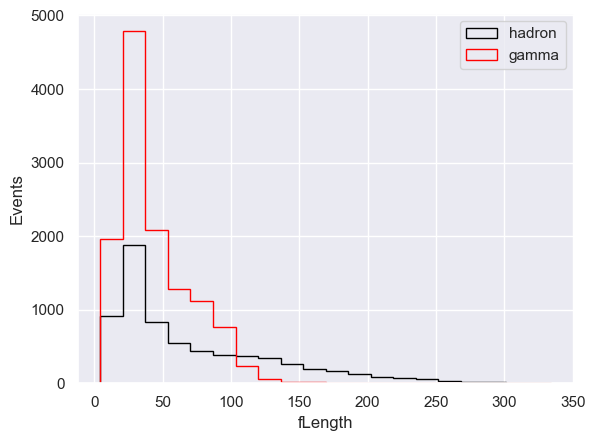

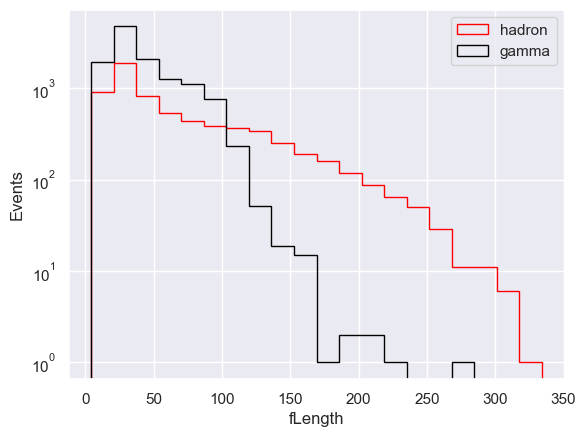

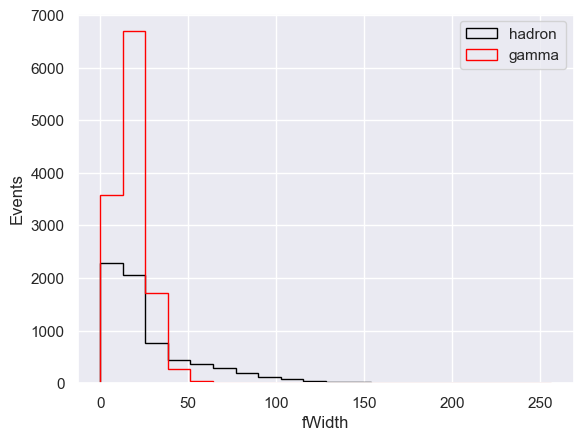

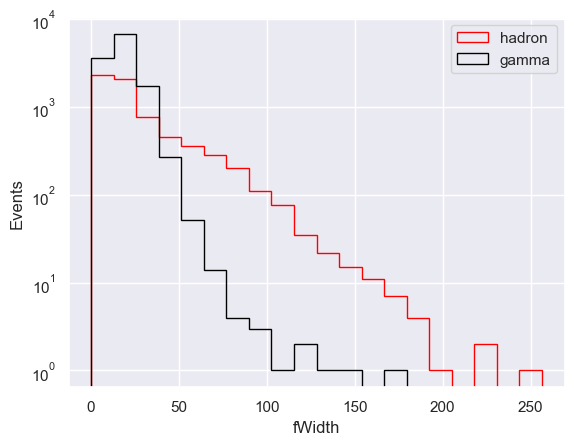

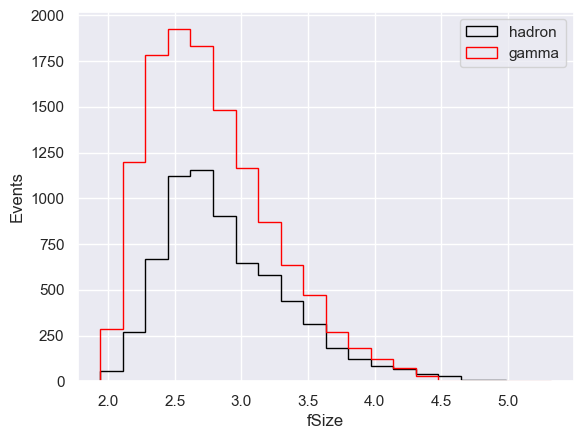

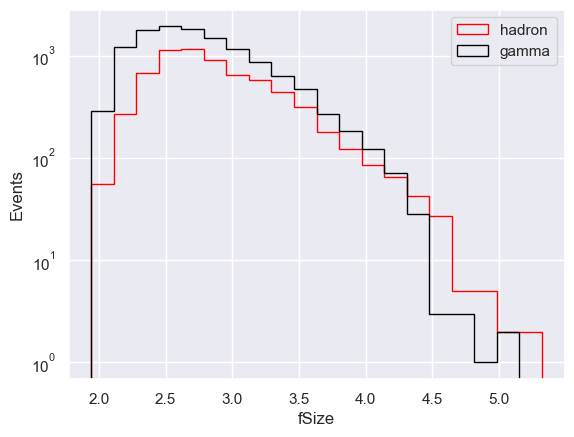

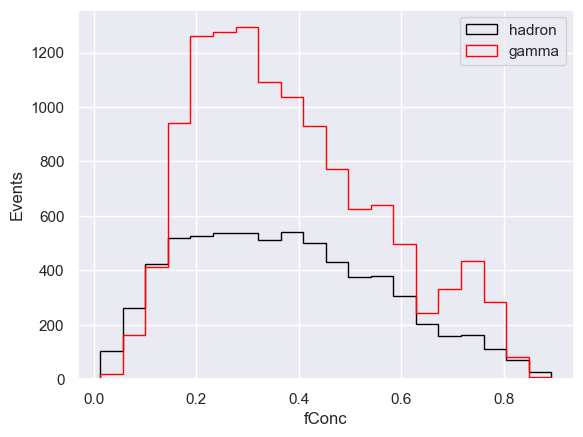

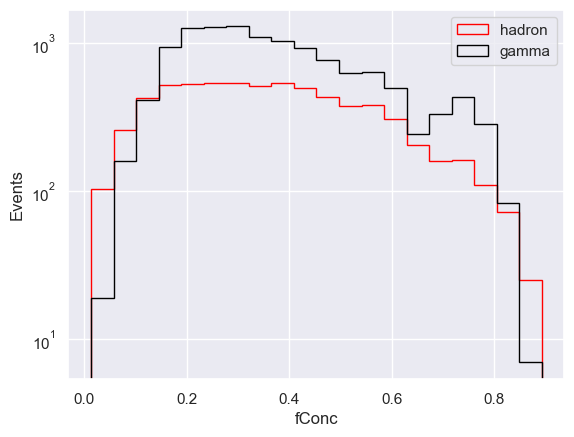

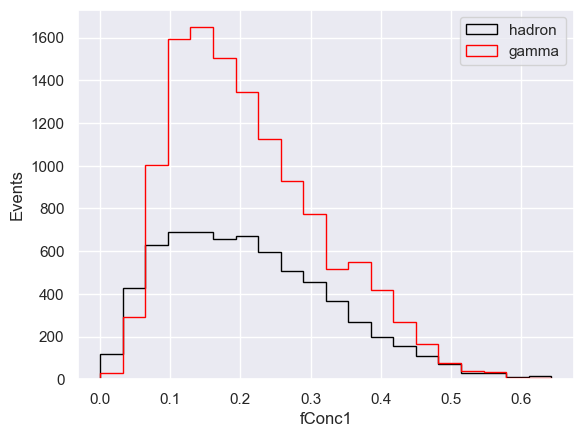

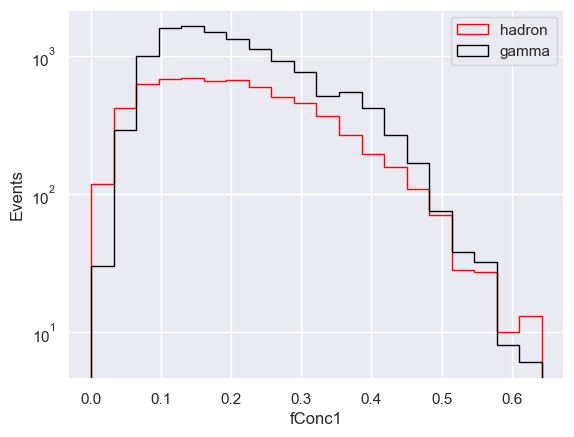

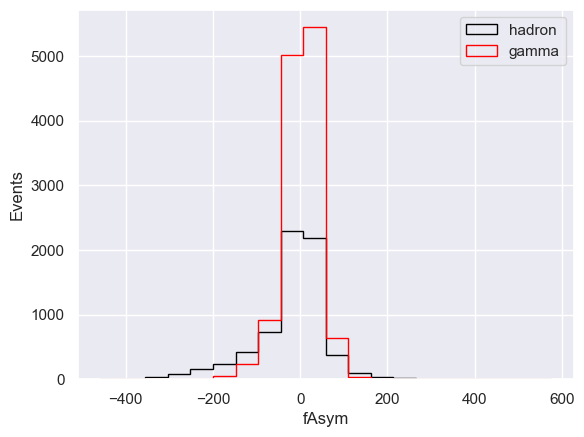

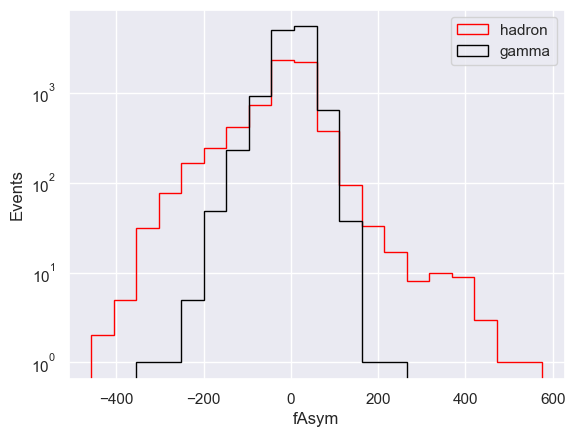

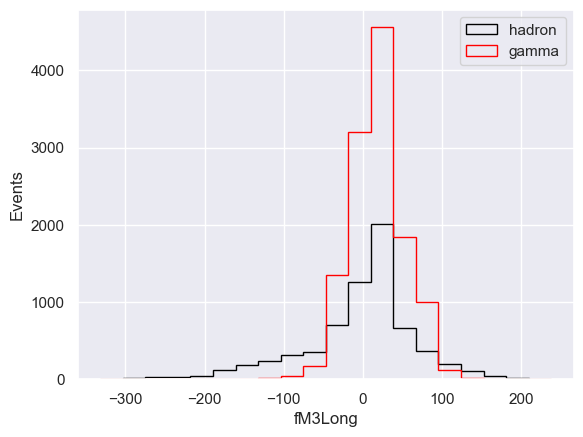

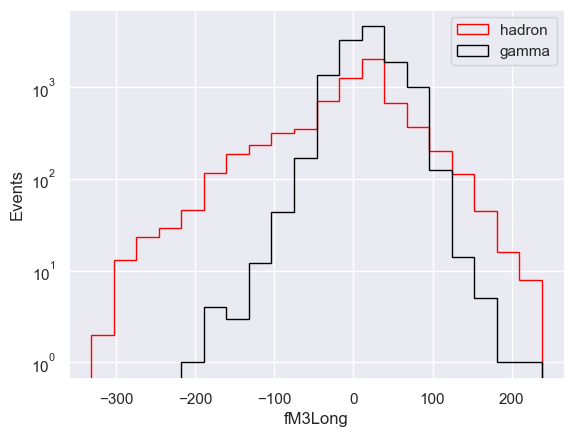

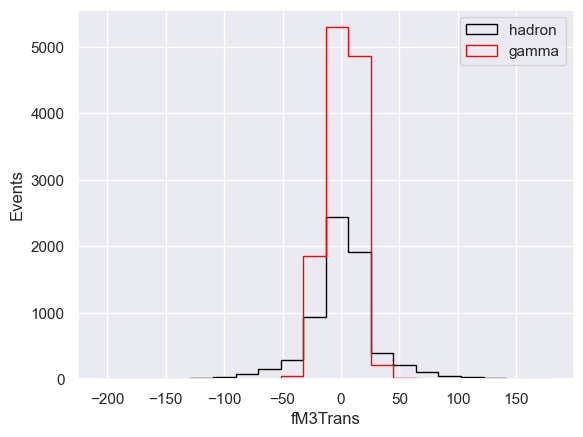

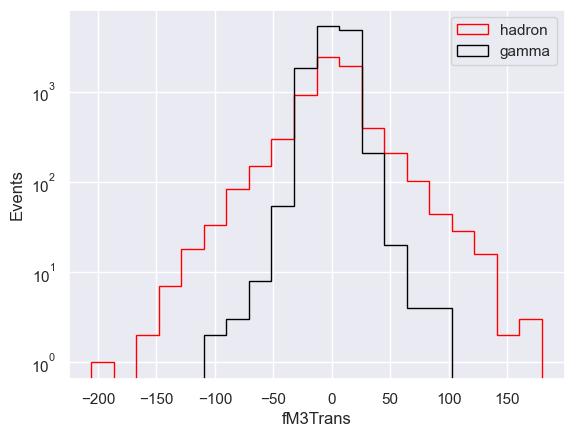

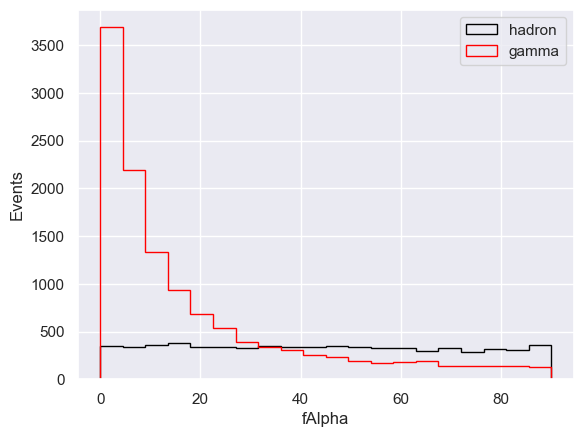

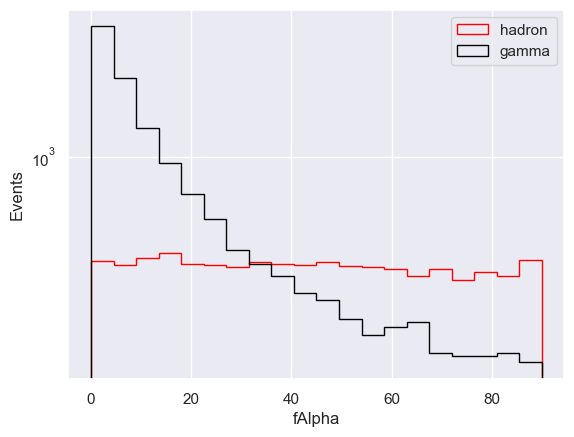

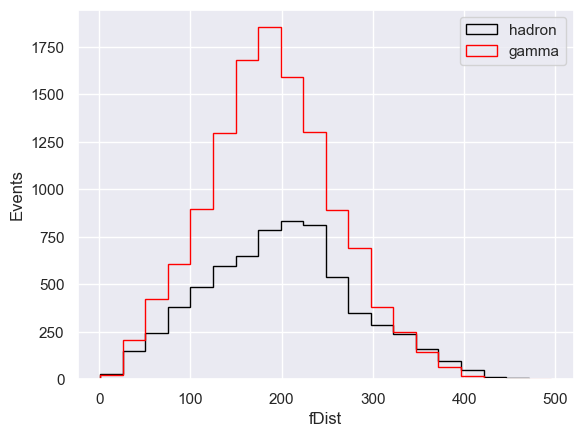

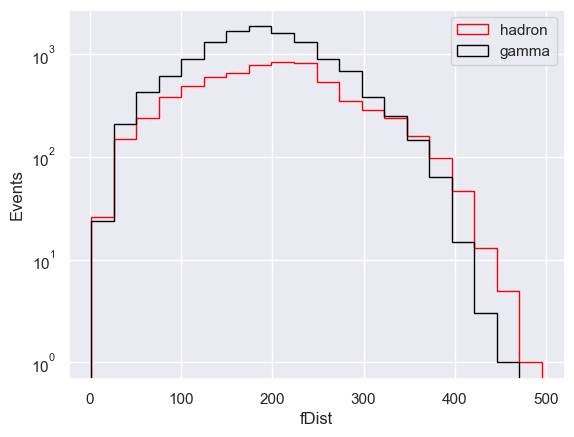

In [23]:
for col in df.columns:

    if col=='class':
        continue
    
    counts,bins,patches = plt.hist(df.loc[df['class']=='h',col], label='hadron', histtype='step', color='black', bins=20)
    plt.hist(df.loc[df['class']=='g',col], label='gamma', histtype='step', color='red', bins=bins)
    plt.legend()
    plt.xlabel(col)
    plt.ylabel('Events')
    plt.savefig('magic-'+col+'.pdf')
    plt.show()

    counts,bins,patches = plt.hist(df.loc[df['class']=='h',col], label='hadron', histtype='step', color='red', bins=20)
    plt.hist(df.loc[df['class']=='g',col], label='gamma', histtype='step', color='black', bins=bins)
    plt.yscale('log')
    plt.legend()
    plt.xlabel(col)
    plt.ylabel('Events')
    plt.savefig('magic-'+col+'-log.pdf')
    plt.show()

These distributions all show some discrimination between signal (gamma) and background (hadron), but we will use a BDT to use as much information as possible to maximise the separation.

First we convert the class label into enumerated values using pandas `factorize()`.

Next we split the dataset into _train_ and _test_ samples, using sci-kit learn `train_test_split()`.


In [4]:
from sklearn.model_selection import train_test_split

X_data = df.loc[:,df.columns.values[0:10]].values
y_data, y_data_uniques = pd.factorize(df.loc[:,'class'].values)
print(y_data_uniques)
h_index = 1
g_index = 0

X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.33, random_state=42)

['fLength' 'fWidth' 'fSize' 'fConc' 'fConc1' 'fAsym' 'fM3Long' 'fM3Trans'
 'fAlpha' 'fDist']
['g' 'h']


Now we are ready to train the BDT, for which we use the `GradientBoostingClassifier` from sci-kit learn.  Note that `HistGradientBoostingClassifier` is also available, and should be more computationally efficient on large samples (>10k).

The hyperparameters are set here, including the number of _estimators_ (number of trees added during boosting), the _learning rate_, and the _max_depth_ of each tree (maximum number of decision nodes).

In [15]:
from sklearn.ensemble import GradientBoostingClassifier

clf = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0, max_depth=1, random_state=0).fit(X_train, y_train)

Now we can generate predictions (i.e. log-odds probabilities for each event to originate from a gamma) for both the test and train samples.

And we can plot their distributions.

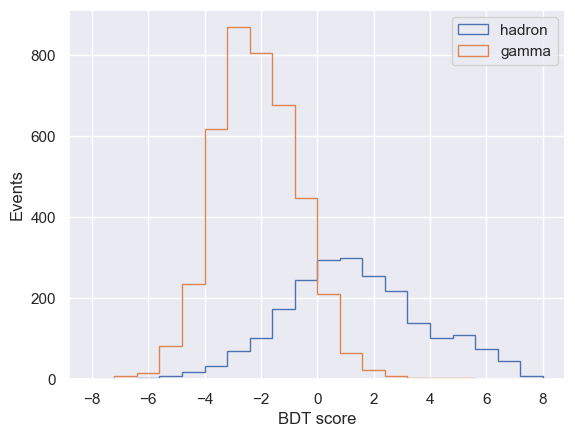

2197.0


In [24]:
scores_test = clf.decision_function(X_test)
scores_train = clf.decision_function(X_train)

n, bins, patches = plt.hist(scores_test[y_test==h_index], label='hadron', histtype='step', bins=20, range=(-8,8))
plt.hist(scores_test[y_test==g_index], label='gamma', histtype='step', bins=bins)
plt.legend()
#plt.yscale('log')
plt.xlabel('BDT score')
plt.ylabel('Events')
plt.savefig('magic-bdt-score-test.pdf')
plt.show()

print(np.sum(n))

And we can convert the log-odds values to probabilities, and plot them (this time for both test and train samples).

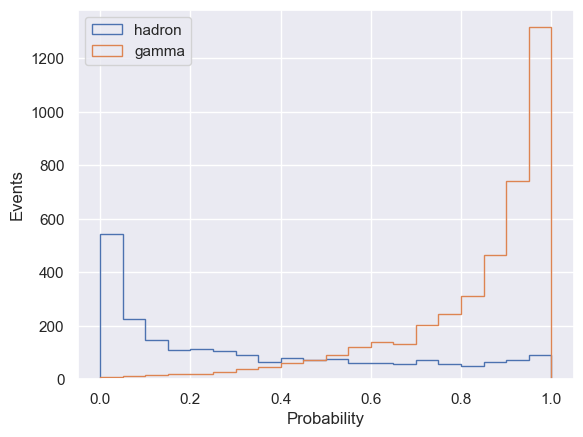

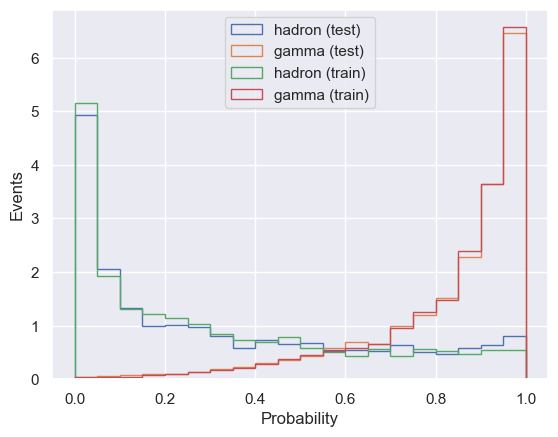

In [25]:
# convert log-odds to probability 
prob_test_h = 1/(1+np.exp(scores_test[y_test==h_index]))
prob_test_g = 1/(1+np.exp(scores_test[y_test==g_index]))
prob_train_h = 1/(1+np.exp(scores_train[y_train==h_index]))
prob_train_g = 1/(1+np.exp(scores_train[y_train==g_index]))

# plot probability distribution for test sample
n, bins, patches = plt.hist(prob_test_h, label='hadron', histtype='step', bins=20)
plt.hist(prob_test_g, label='gamma', histtype='step', bins=bins)
plt.legend()
#plt.yscale('log')
plt.xlabel('Probability')
plt.ylabel('Events')
plt.savefig('magic-bdt-prob-test.pdf')
plt.show()

# plot probability distribution for both test and train samples
n, bins, patches = plt.hist(prob_test_h, label='hadron (test)', histtype='step', bins=20, density=True)
plt.hist(prob_test_g, label='gamma (test)', histtype='step', bins=bins, density=True)
plt.hist(prob_train_h, label='hadron (train)', histtype='step', bins=bins, density=True)
plt.hist(prob_train_g, label='gamma (train)', histtype='step', bins=bins, density=True)
plt.legend()
#plt.yscale('log')
plt.xlabel('Probability')
plt.ylabel('Events')
plt.savefig('magic-bdt-prob.pdf')
plt.show()


In order to classify an event as gamma or hadron, we need to define and set a threshold on the BDT predicted probability. To determine the optimal threshold, we computer several metrics and plot them as a function of threshold.  Including :

__True Positive Rate (TPR)__
The fraction of true gamma events identified as gamma.

__False Positive Rate (TPR)__
The fraction of true hadron events identified as gamma.

__True Negative Rate (TPR)__
The fraction of true hadron events identified as hadron.

__False Negative Rate (TPR)__
The fraction of true gamma events identified as hadron.

We plot each of these metrics as a function of the threshold on probability, $P_{thresh}$.


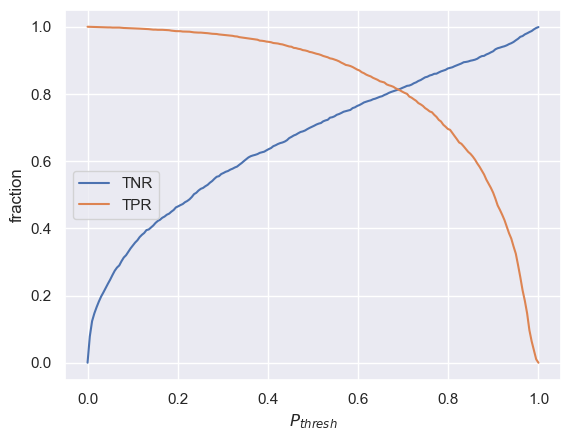

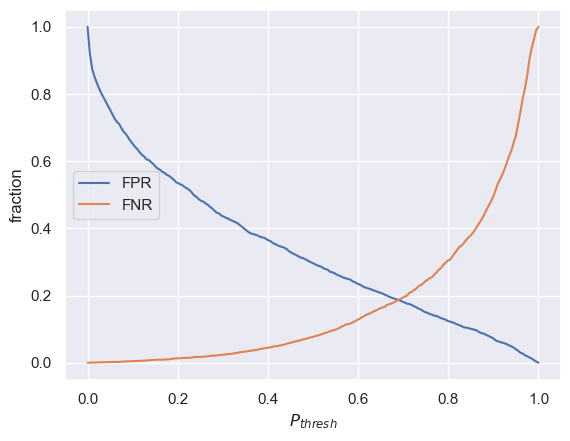

In [26]:
# get arrays of scores for true hadron and gamma classes
score_thresh = np.linspace(0, 1, 200)

# calculate metrics using list comprehension to scan over thresholds
tpr = [ (prob_test_g>score).sum()/len(prob_test_g) for score in score_thresh  ] 
fpr = [ (prob_test_h>score).sum()/len(prob_test_h) for score in score_thresh  ]
tnr = [ (prob_test_h<score).sum()/len(prob_test_h) for score in score_thresh  ] 
fnr = [ (prob_test_g<score).sum()/len(prob_test_g) for score in score_thresh  ] 

# plot TPR/TNR
plt.plot(score_thresh, tnr, label='TNR')
plt.plot(score_thresh, tpr, label='TPR')
plt.legend()
plt.ylabel('fraction')
plt.xlabel('$P_{thresh}$')
plt.savefig('magic-bdt-tpr.pdf')
plt.show()

# plot FPR/FNR
plt.plot(score_thresh, fpr, label='FPR')
plt.plot(score_thresh, fnr, label='FNR')
plt.legend()
plt.ylabel('fraction')
plt.xlabel('$P_{thresh}$')
plt.savefig('magic-bdt-fpr.pdf')
plt.show()

We can now easily plot the Receiver Operating Characteristic (ROC) curve, which is simple the TPR against the FPR.

We can also compute the area under the ROC curve, using numerical integration.

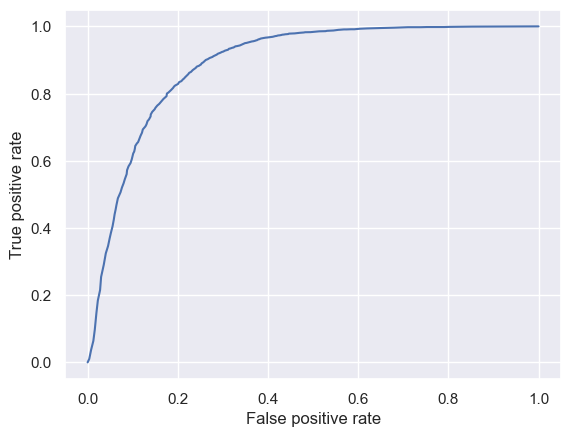

0.8882774986955253


In [27]:
# ROC
plt.plot(fpr, tpr)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.savefig('magic-bdt-roc.pdf')
plt.show()

#AUC
auc = np.trapz(x=fpr[::-1], y=tpr[::-1])
print("AUC = ",auc)

For a given value of the threshold, we may also wish to show the confusion matrix.

In [28]:
# confusion matrix
thresh = 0.85
tp_cm = (prob_test_g>thresh).sum()
tn_cm = (prob_test_h<thresh).sum()
fn_cm = (prob_test_g<thresh).sum()
fp_cm = (prob_test_h>thresh).sum()

print(tp_cm, fn_cm)
print(fp_cm, tn_cm) 

2521 1550
223 1983


Lastly, the cell below contains some code which can extract and plot the trees from the GradientBoostingClassifier.

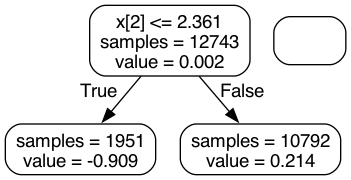

In [16]:
from pydotplus import graph_from_dot_data
from sklearn.tree import export_graphviz
from IPython.display import Image

gbc_sub_tree = clf.estimators_[2, 0]

graph_data = export_graphviz(gbc_sub_tree, out_file=None, rounded=True, proportion=False, impurity=False)
tree_graph = graph_from_dot_data(graph_data)
tree_graph.write_png('tree1.png')
Image(tree_graph.create_png())

# MLP version

Below here I try to create an MLP classifier...


In [ ]:
from sklearn import preprocessing
from sklearn.neural_network import MLPClassifier

scaler = preprocessing.StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf2 = MLPClassifier(solver='sgd', alpha=1e-5, hidden_layer_sizes=(10, 5), activation='relu', random_state=1, max_iter=10000, early_stopping=True)

clf2.fit(X_train_scaled, y_train)

In [ ]:
print(clf2.score(X_test_scaled, y_test))
scores2_g = clf.predict_proba(X_test_scaled)[:,g_index]
scores2_h = clf.predict_proba(X_test_scaled)[:,h_index]
print(scores2_g, scores2_h)

In [ ]:
logbins = np.geomspace(0.9, 1, 20)

n, bins, patches = plt.hist(scores2_g[y_test==h_index], label='hadron', histtype='step', bins=logbins, density=True)
plt.hist(scores2_g[y_test==g_index], label='gamma', histtype='step', bins=logbins, density=True)
plt.legend()
#plt.yscale('log')
plt.xscale('log')
plt.xlabel('MLP score')
plt.ylabel('Events')
plt.savefig('magic-mlp-score.pdf')
plt.show()

n, bins, patches = plt.hist(scores2_h[y_test==h_index], label='hadron', histtype='step', bins=logbins, density=True)
plt.hist(scores2_h[y_test==g_index], label='gamma', histtype='step', bins=logbins, density=True)
plt.legend()
#plt.yscale('log')
plt.xscale('log')
plt.xlabel('MLP score')
plt.ylabel('Events')
plt.savefig('magic-mlp-score.pdf')
plt.show()

In [ ]:
# get arrays of scores for true hadron and gamma classes
scores2_g_false = scores2_g[y_test==h_index]
scores2_g_true  = scores2_g[y_test==g_index]

score_thresh = np.linspace(0, 1, 200)

tpr = [ (scores2_g_true>score).sum()/len(scores2_g_true) for score in score_thresh  ] 
fpr = [ (scores2_g_false>score).sum()/len(scores2_g_false) for score in score_thresh  ]
tnr = [ (scores2_g_false<score).sum()/len(scores2_g_false) for score in score_thresh  ] 
fnr = [ (scores2_g_true<score).sum()/len(scores2_g_true) for score in score_thresh  ] 

plt.plot(score_thresh, tnr, label='TNR')
plt.plot(score_thresh, tpr, label='TPR')
plt.legend()
plt.ylabel('fraction')
plt.xlabel('score')
plt.savefig('magic-bdt-tpr.pdf')
plt.show()

plt.plot(score_thresh, fpr, label='FPR')
plt.plot(score_thresh, fnr, label='FNR')
plt.legend()
plt.ylabel('fraction')
plt.xlabel('score')
plt.savefig('magic-bdt-fpr.pdf')
plt.show()



In [ ]:
print(y_data_uniques)

In [ ]:
print(19020-4482-2206)

In [ ]:
print(len(X_train))